In [5]:
# Importing Libraries
import os
import glob
import datetime
#import cartopy
import re

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#import pyleoclim as pyleo

from math import pi
from windrose import WindroseAxes
from matplotlib import pyplot

#%matplotlib notebook
# CLSU data is better suited than Science Center for BNBNP

In [6]:
class Monitor:
    
    def __init__(self, cave_path, inst_path, chem_water_path):

        self.chem_water_path= chem_water_path
        self.cave_path = cave_path
        self.inst_path = inst_path
        self.cave_dict = {
            'Bulacan':['hobo_entrance.csv', 'hobo_interior.csv',
                    'stal_fast.csv', 'stal_slow.csv','Vaisala_Bulacan_.csv'], 
            'Palawan':['chocfountain_hobo.csv', 'stumpy_hobo.csv',
                    'chocfountain_stalagmate.csv', 'stumpy_stalagmate.csv', 
                      'twins_stalagmate.csv', 'goblin_stalagmate.csv',
                       'goblin_hobo.csv', 'stumpy_stalagmate.csv','Vaisala.csv'], 
            'Bangalau':[]
                    } 
        self.cave_df       = {}
        self.instr_df      = {}
        self.chem_water_df = {}
      
    def load_cave( self ):  
        # LOOP OVER CAVES       
        for cave_name, cave_site in self.cave_dict.items():
            
            #print('---------------')
            #print(cave_name, cave_site)
            
            l_df = []     
            
            # LOOP OVER FILES   
            for s in cave_site:
                
                site_path = os.path.join( self.cave_path, cave_name, s )
                df_site = pd.read_csv( site_path )
                df_site.dropna(subset=['Time'], inplace=True)

                df_site['Time'] = pd.to_datetime(df_site['Time'], format = '%m/%d/%y %H:%M')
                ## DAILY MEANS ##
                df_site.set_index('Time', inplace=True)
                df_site_daily   = df_site.resample('D').mean().reset_index(names = 'Date')

                l_df.append(df_site_daily)

            self.cave_df[cave_name] = self.merge_df( *l_df  ) 
            
    
    def load_inst( self ):
        # LOOP OVER INSTRUMENTAL DATA
        csv_files = glob.glob( os.path.join(self.inst_path, "*.csv") )
        
        # LOOP OVER THE LIST OF FILES IN THE FOLDER
        for f in csv_files:
            
            file_name = f.split('/')[-1]
            
            self.instr_df[file_name] = pd.read_csv( f, na_values=['-999'],parse_dates = { 'Date': ['YEAR', 'MONTH', 'DAY'] } )

    
    def load_chem( self ):
        # LOOP OVER CHEM ANION and CATION DATA
        xls_files = glob.glob( os.path.join(self.chem_water_path, '*.xlsx') )
        #print(xls_files)
        for f in xls_files:
            file_name = f.split('/')[-1]
            #print(file_name)
            chem = {}
            for sheet in pd.ExcelFile(f).sheet_names:
                chem[f'{sheet}']= pd.read_excel(f,sheet_name=sheet)
            
            self.chem_water_df[f'{file_name}'] = chem
        #display( self.chem_water_df )
    
    
    def merge_df (self, *df):
        
        if len(df) ==1:
            return df[0]
            
        df_merge = None
        
        for count, d  in enumerate(df): 
            if count == 0 :  
                df_merge = d
                
            else :
                df_merge = pd.merge( df_merge, d, how = 'outer', on = 'Date')   
        
        return df_merge
                   
    
    
    def summary_plot(self):

        # CAVE DATA SUMMARY PLOT
        for cave_name, df in self.cave_df.items():
            if df is None:
                print(f'{cave_name} has been skipped because of no data')
                continue
            display(df.columns)
            print(f'========= THIS HAS CAVE DATA PLOTs FOR {cave_name} ===============')
            f, (ax1, ax2, ax3) = plt.subplots( 3, 1, figsize = (10,20), sharex=True )
            ax1.plot( df['Date'], df[ df.columns[9]] ,'k', linewidth = 1 )
            ax1.set_ylabel('CO2 (ppm)')
            ax2.plot( df['Date'], df[ df.columns[1]] )
            ax2.plot( df['Date'], df[ df.columns[2]] )
            ax2.set_ylabel('Cave-Air Temperature (°C)')
            ax3.plot( df['Date'], df[ df.columns[5]] )
            ax3.plot( df['Date'], df[ df.columns[8]] )
            ax3.set_ylabel('Drip Rate (ml/min)')
            f.suptitle(cave_name)
            f.autofmt_xdate()
            #f.savefig('Figures/Puerto_Modern.eps')
            plt.show()
        
        # INSTRUMENTAL DATA SUMMARY PLOT
        for instr_name, df in self.instr_df.items():
            print(f'========= THIS HAS INSTR PLOTs FOR {instr_name} ===============')
            f, (ax1, ax3) = plt.subplots( 2, 1, figsize = (10,20), sharex=True )
            # INSTRUMENTAL DATA
            ax1.plot( df['Date'], df[ df.columns[4] ], 'k', alpha = 0.5, linewidth = 1 )
            ax1.set_ylabel( 'Surface-Air Temperature (°C)' )
            ax2 = ax1.twinx()
            ax2.bar( df['Date'], df[ df.columns[1] ], width = 1 )
            ax2.set_ylabel( 'Daily Rainfall (mm)' )
            ax3.bar( df['Date'], df[ df.columns[8]], width = 1 )
            ax3.set_ylabel( 'Surface-Air Pressure (mbar)' )
            #ax3.set_ylim([980, 1011])
            ax4 = ax3.twinx()
            ax4.plot( df['Date'], df[ df.columns[6]], 'k', linewidth = 1 )
            ax4.set_ylabel( 'Wind Speed (m/s)' )
            ax1.set_xlim([datetime.date(2022, 3, 1), datetime.date(2023, 7, 1)])
            f.suptitle(instr_name)
            f.autofmt_xdate()
            #f.savefig('Figures/'+f'{f}.eps')
            # WIND ROSE PLOTS 
            print(f'========= THIS HAS WIND ROSE PLOTs FOR {instr_name} ===============')
            df['velocidad_x'] = df['WIND_SPEED'] * np.sin(df['WIND_DIRECTION'] * pi / 180.0)
            df['velocidad_y'] = df['WIND_SPEED'] * np.cos(df['WIND_DIRECTION'] * pi / 180.0)
            ax = WindroseAxes.from_ax()
            ax.bar(df.WIND_DIRECTION, df.WIND_SPEED, normed=True, opening=0.8, edgecolor='white')
            ax.set_legend()
            #ax.savefig('Figures/'+f'{instr_name}_windrose.eps')  
            plt.show()
            
        # CHEMICAL DATA SUMMARY PLOT
        anion_list = ['F-','Cl-','NO3-', 'SO42-']
        cation_list= ['Sr/Ca_mmol/mol','K/Ca_mmol/mol','Na/Ca_mmol/mol','Mg/Ca_mmol/mol']

        for file_name, data in self.chem_water_df.items():
            
            loop_list = []
            
            if 'Cations' in file_name: 
                loop_list = cation_list
            else:
                loop_list = anion_list

            for cave_name in data:
                
                for ion in loop_list:
                    pd.pivot_table(self.chem_water_df[file_name][cave_name].reset_index(),
                                  index='Date', columns='Site Name', values=ion
                                  ).plot(subplots=False,linestyle = 'None', marker='o')
                    plt.title(f'{cave_name}')
                    plt.xlabel('Date')
                    plt.ylabel(f'{ion}')
                    if 'Anion' in file_name:
                        plt.ylabel(f'{ion}ppm')

############ FIN #################


Index(['Date', 'Entrance_Temp', 'Interior_Temp', 'Fast_Count',
       'fast_drops/minute', 'fast_ml/min', 'Slow_Count', 'slow_drops/minute',
       'slow_ml/min', 'CO2'],
      dtype='object')

========= THIS HAS CAVE DATA PLOTs FOR Bulacan ===============


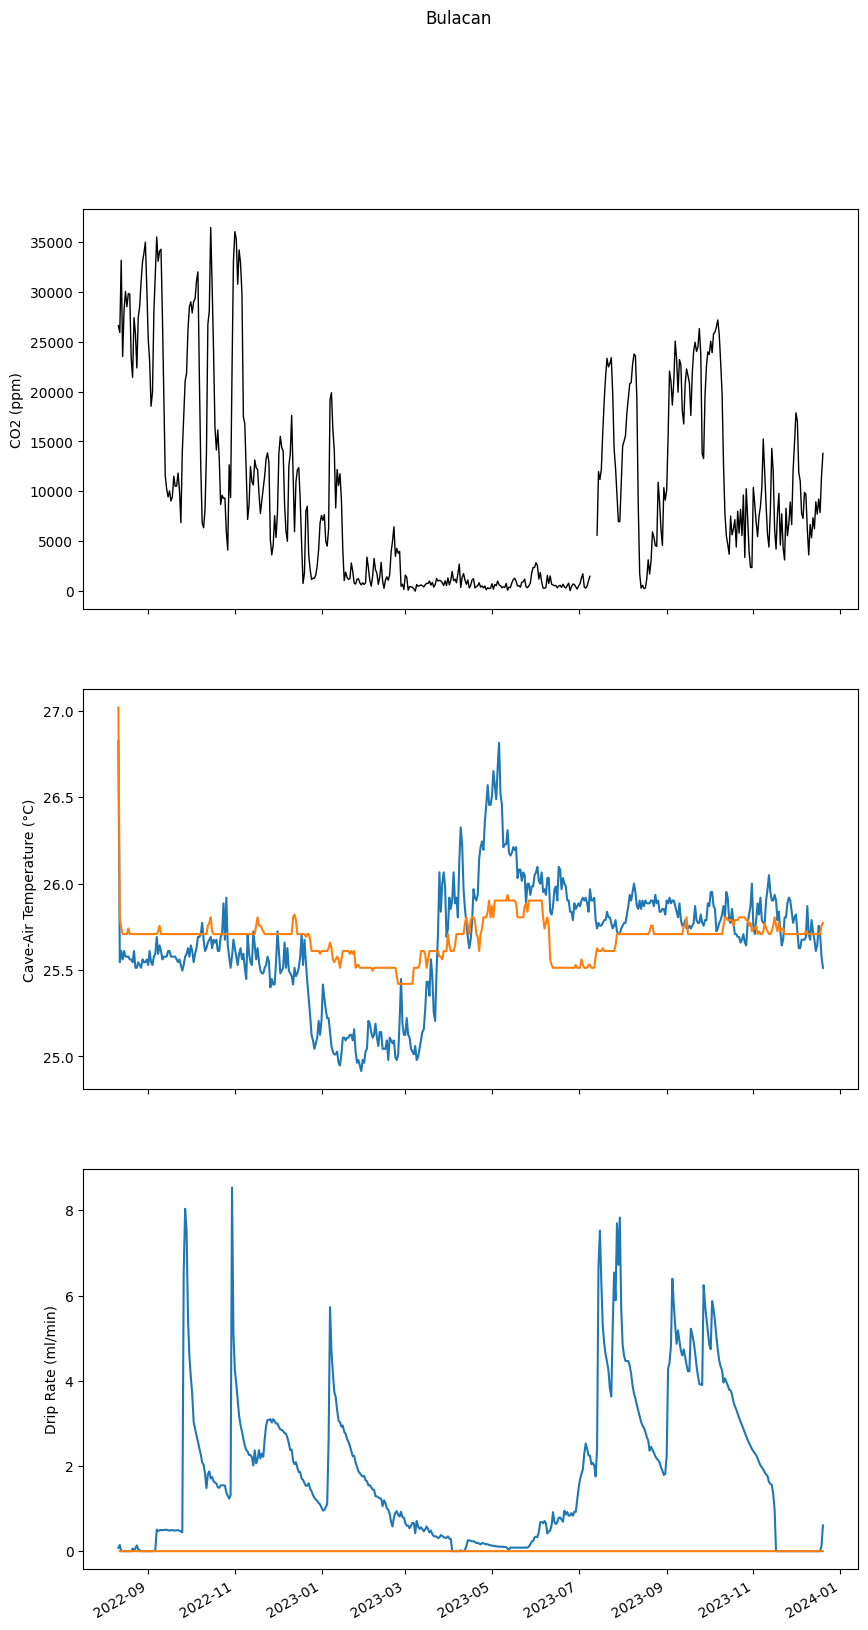

Index(['Date', 'CF_Temp', 'Stumpy_Temp', 'CF_Counts', 'cf_drops/minute',
       'cf_ml/min', 'Stumpy_Counts_x', 'stumpy_drops/minute_x',
       'stumpy_ml/min_x', 'twins_Counts', 'twins_drops/minute', 'twins_ml/min',
       'goblin_Counts', 'goblin_drops/minute', 'goblin_ml/min', 'Goblin_Temp',
       'Stumpy_Counts_y', 'stumpy_drops/minute_y', 'stumpy_ml/min_y', 'CO2, %',
       'ppm'],
      dtype='object')

========= THIS HAS CAVE DATA PLOTs FOR Palawan ===============


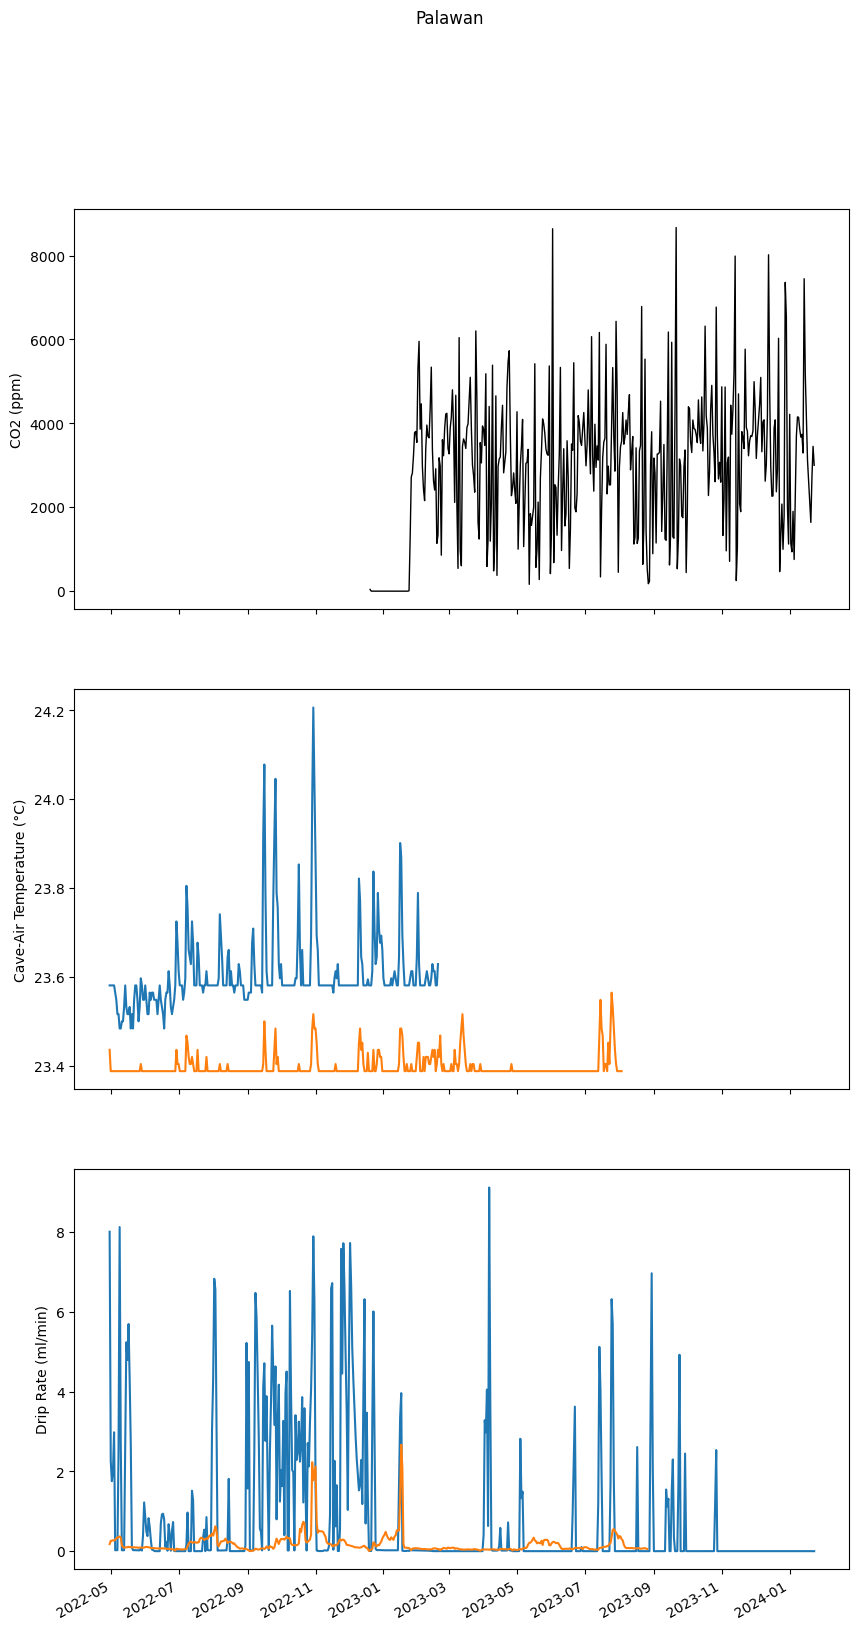

Bangalau has been skipped because of no data
========= THIS HAS INSTR PLOTs FOR Science Garden Daily Data.csv ===============
========= THIS HAS WIND ROSE PLOTs FOR Science Garden Daily Data.csv ===============


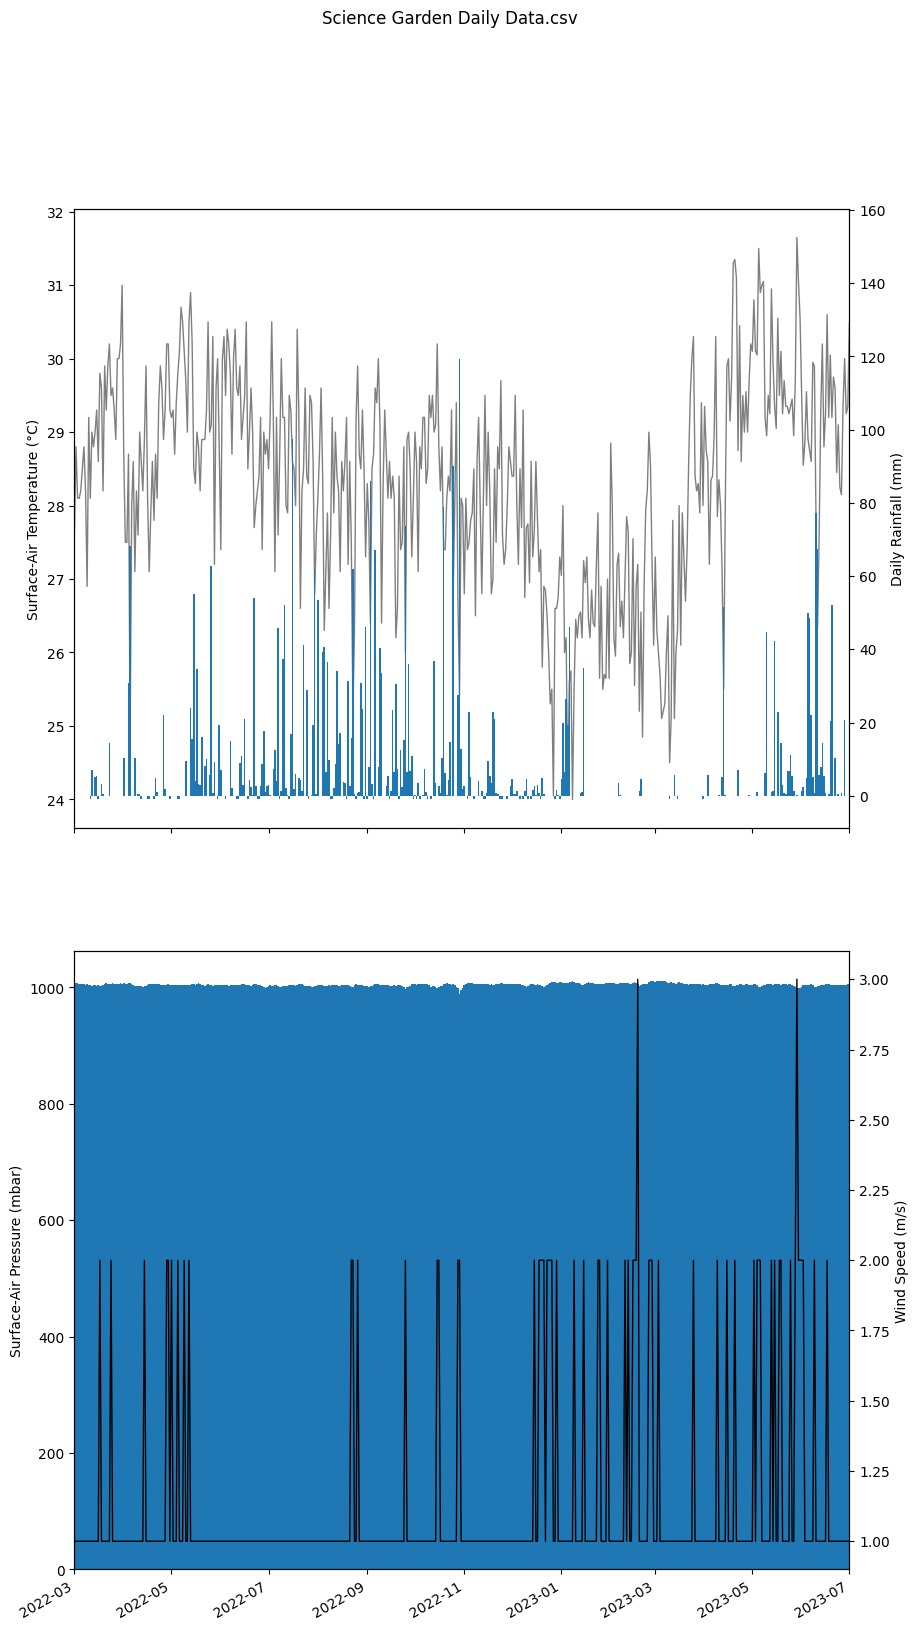

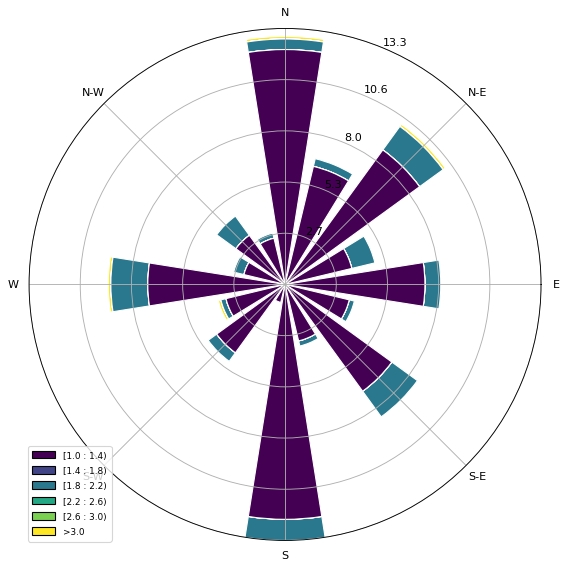

========= THIS HAS INSTR PLOTs FOR Puerto.csv ===============
========= THIS HAS WIND ROSE PLOTs FOR Puerto.csv ===============


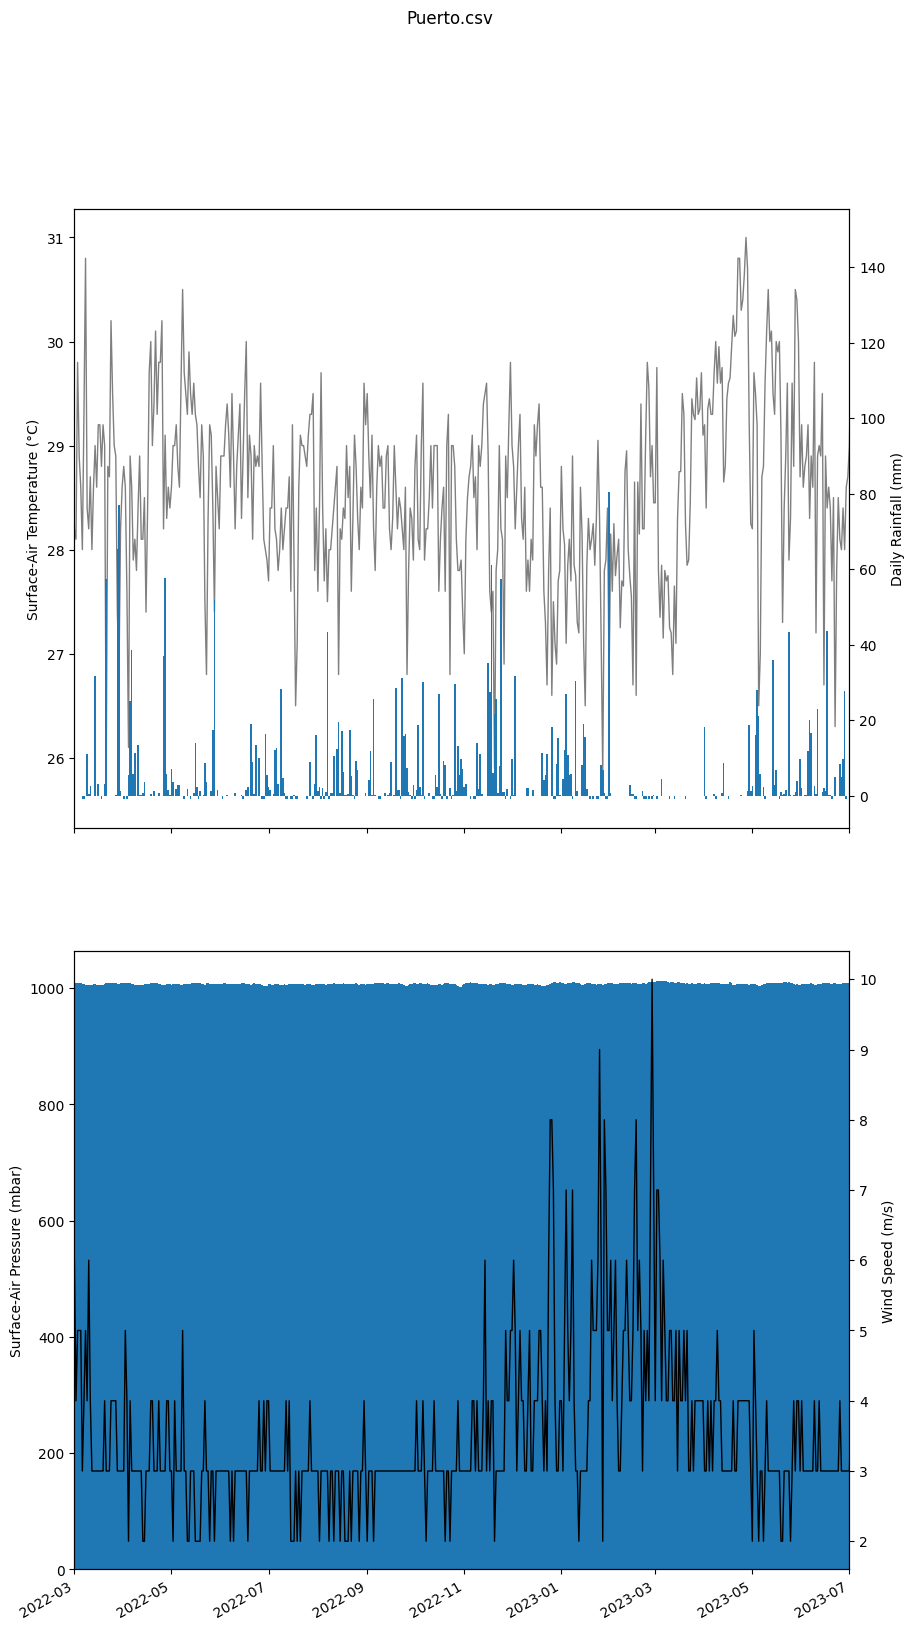

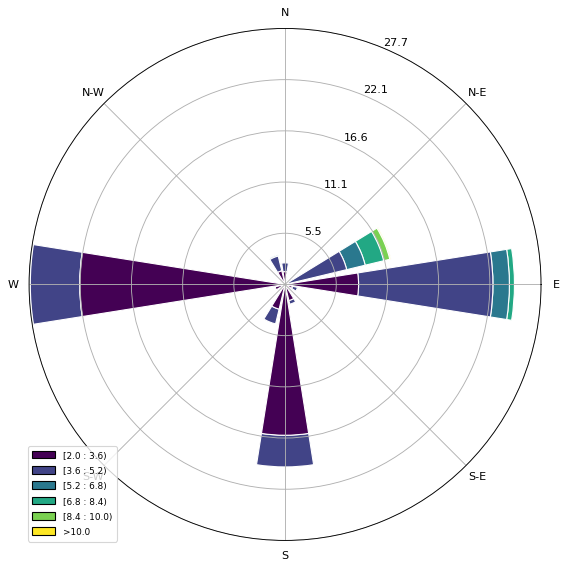

========= THIS HAS INSTR PLOTs FOR CLSU.csv ===============
========= THIS HAS WIND ROSE PLOTs FOR CLSU.csv ===============


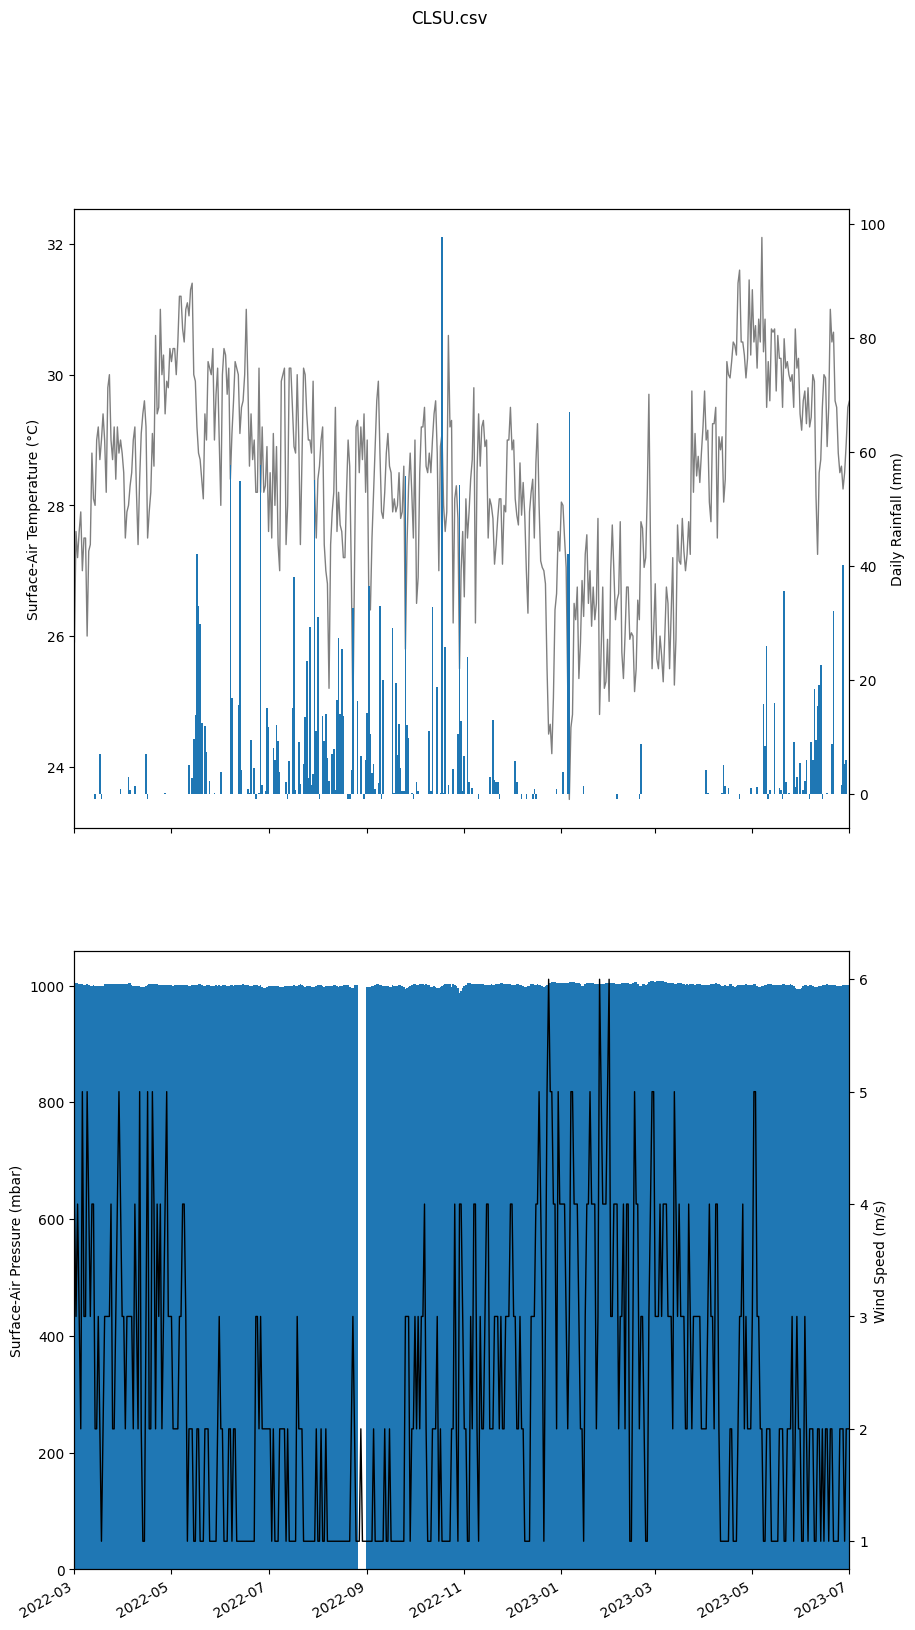

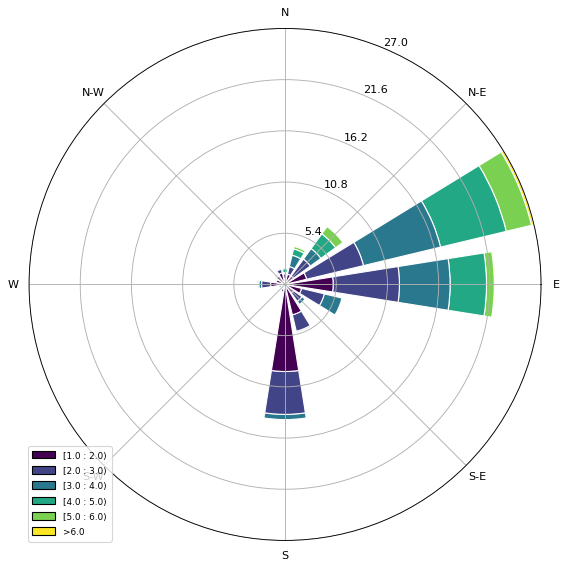

========= THIS HAS INSTR PLOTs FOR Aparri.csv ===============
========= THIS HAS WIND ROSE PLOTs FOR Aparri.csv ===============


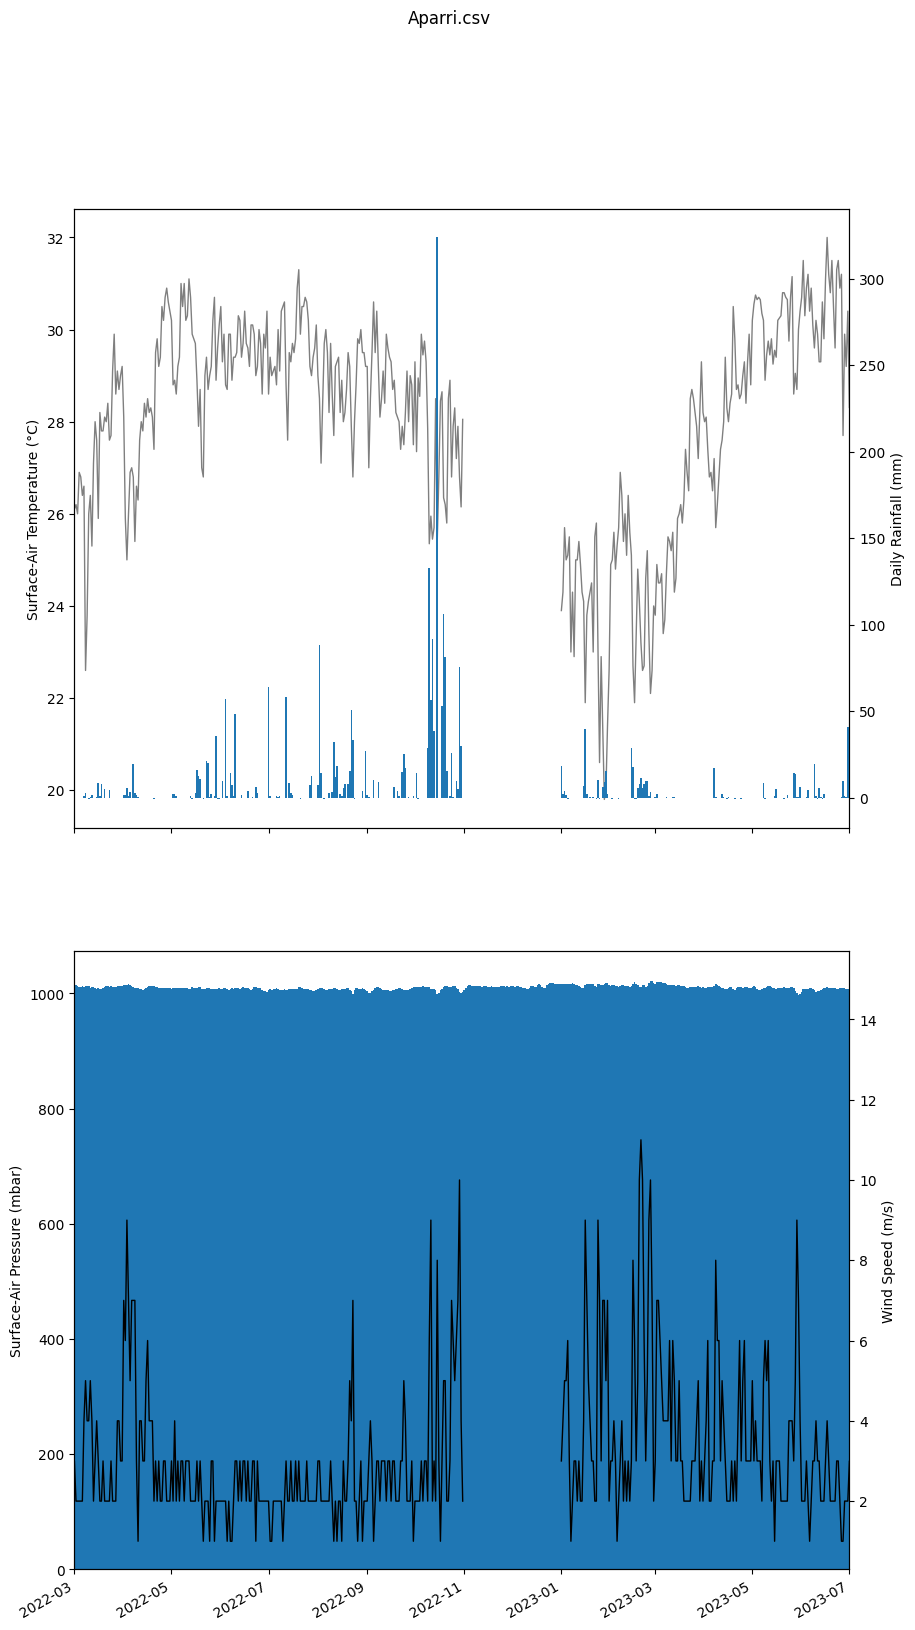

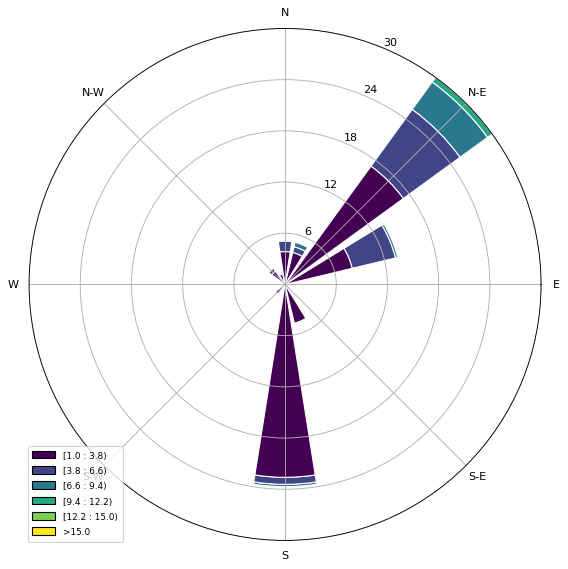

In [7]:
# RUN CODE
m = Monitor( cave_path = 'Data/Caves/' , 
            inst_path = 'Data/Instrumental/', 
            chem_water_path = 'Data/Chemical/Water/' )

m.load_cave()
m.load_inst()
#m.load_chem()
m.summary_plot()

In [9]:
water_stable_path = 'Data/Chemical/stable_iso/water_stable.xlsx'

# ISOTOPE DATA  >>> CHANGE IT TO AMOUNT WEIGHTED DATA 
ppur_iso  = pd.read_excel(water_stable_path, sheet_name='PPUR_IAEA')
banga_iso = pd.read_excel(water_stable_path, sheet_name='Bangalau_IAEA')
bnb_iso   = pd.read_excel(water_stable_path, sheet_name='BNB_IAEA')
gmwl_iso  = pd.read_excel(water_stable_path, sheet_name='gmwl')

gnip_manila= pd.read_excel('Data/Chemical/stable_iso/gnip_manila.xlsx',sheet_name= 'Sheet1')
gnip_manila['End of Period'] = pd.to_datetime(gnip_manila['End of Period'])
gnip_manila = gnip_manila.set_index('End of Period')
#gnip_manila_month= pd.read_excel('Data/Chemical/gnip_monthly_all.xlsx',sheet_name= 'reduced')

# closed right indicates that the last value is included in the mean calculation
gnip_018 = gnip_manila['O18'].resample('3M',label='right', closed='right').mean()
gnip_H2 = gnip_manila['H2'].resample('3M', label='right', closed='right').mean()
gnip_DE = gnip_manila['Dexcess'].resample('3M', label='right', closed='right').mean()


In [39]:
### PIVOTING DATA

def drip_pivot(cave, parameter):
    iso_stable = pd.pivot_table(cave.reset_index(),index='Date', columns='Site Name', values=parameter)
    return iso_stable

bnb_o18 = drip_pivot(bnb_iso, 'd18o')
bnb_h   = drip_pivot(bnb_iso, 'dH')

ppur_o18 = drip_pivot(ppur_iso, 'd18o')
ppur_h   = drip_pivot(ppur_iso, 'dH')

banga_o18 = drip_pivot(banga_iso, 'd18o')
banga_h   = drip_pivot(banga_iso, 'dH')


0    2022-05-04
1    2022-07-16
2    2022-09-13
3    2022-11-08
4    2022-12-15
5    2023-01-28
6    2023-03-18
7    2023-05-13
dtype: object


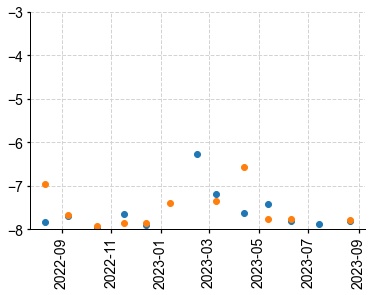

In [57]:
plt.scatter(bnb_o18.index,bnb_o18['Fast'].values)
plt.scatter(bnb_o18.index,bnb_o18['Slow'].values)
plt.ylim(-8, -3)
plt.xticks(rotation=90)
plt.savefig('Figures/bnb_o18_AGU2023.eps')

(array([19113., 19174., 19236., 19297., 19358., 19417., 19478.]),
 [Text(19113.0, 0, '2022-05'),
  Text(19174.0, 0, '2022-07'),
  Text(19236.0, 0, '2022-09'),
  Text(19297.0, 0, '2022-11'),
  Text(19358.0, 0, '2023-01'),
  Text(19417.0, 0, '2023-03'),
  Text(19478.0, 0, '2023-05')])

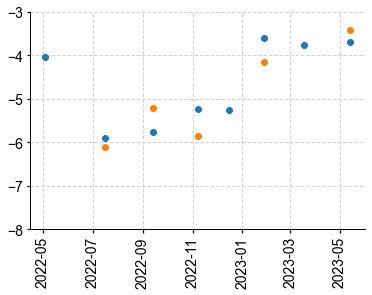

In [69]:
plt.scatter(banga_o18.index,banga_o18['Pancake'].values)
plt.scatter(banga_o18.index,banga_o18['Needle'].values)
plt.ylim(-8, -3)
plt.xticks(rotation=90)
#plt.savefig('Figures/banga_o18_AGU2023.eps')

(array([19174., 19236., 19297., 19358., 19417., 19478., 19539., 19601.]),
 [Text(19174.0, 0, '2022-07'),
  Text(19236.0, 0, '2022-09'),
  Text(19297.0, 0, '2022-11'),
  Text(19358.0, 0, '2023-01'),
  Text(19417.0, 0, '2023-03'),
  Text(19478.0, 0, '2023-05'),
  Text(19539.0, 0, '2023-07'),
  Text(19601.0, 0, '2023-09')])

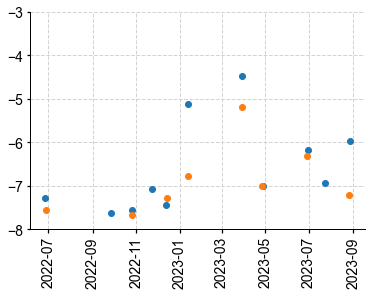

In [78]:
plt.scatter(ppur_o18.index,ppur_o18['Chocolate Fountain'].values)
plt.scatter(ppur_o18.index,ppur_o18['Stumpy'].values)
plt.ylim(-8, -3)
plt.xticks(rotation=90)
#plt.savefig('Figures/ppur_o18_AGU2023.eps')


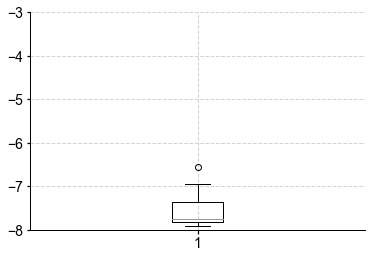

In [105]:

# Creating plot
plt.boxplot(bnb_o18['Slow'].values[~np.isnan(bnb_o18['Slow'].values)])
plt.ylim(-8, -3.0)
plt.savefig('Figures/bnb_slow_box.eps')
plt.show()

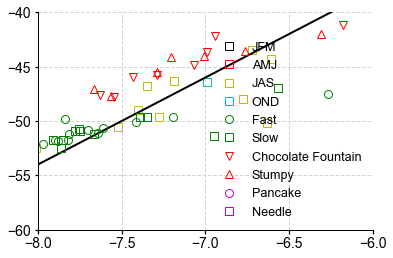

In [45]:
#### BI-VARIATE PLOT

plt.plot(gnip_018[gnip_018.index.month==1].mean(), gnip_H2[gnip_H2.index.month==1].mean(),
         'ks', markerfacecolor = 'none', markersize = 8, label = 'JFM' )

plt.plot(gnip_018[gnip_018.index.month==4].mean(), gnip_H2[gnip_H2.index.month==4].mean(),
         'rs', markerfacecolor = 'none', markersize = 8, label = 'AMJ' )

plt.plot(gnip_018[gnip_018.index.month==7], gnip_H2[gnip_H2.index.month==7], 
         'ys', markerfacecolor = 'none', markersize = 8, label = 'JAS' )

plt.plot(gnip_018[gnip_018.index.month==10].mean(), gnip_H2[gnip_H2.index.month==10].mean(), 
         'cs', markerfacecolor = 'none', markersize = 8, label = 'OND' )

plt.plot(gmwl_iso['O'], gmwl_iso['D'], color = 'black')

plt.plot(bnb_o18['Fast'].values,bnb_h['Fast'].values, 'go', markerfacecolor = 'none', markersize = 8, label = 'Fast')
plt.plot(bnb_o18['Slow'].values,bnb_h['Slow'].values, 'gs', markerfacecolor = 'none', markersize = 8, label = 'Slow')

plt.plot(ppur_o18['Chocolate Fountain'].values,ppur_h['Chocolate Fountain'].values, 'rv', markerfacecolor = 'none', markersize = 8, label = 'Chocolate Fountain')
plt.plot(ppur_o18['Stumpy'].values,ppur_h['Stumpy'].values, 'r^', markerfacecolor = 'none', markersize = 8, label = 'Stumpy')

plt.plot(banga_o18['Pancake'].values,banga_h['Pancake'].values, 'mo', markerfacecolor = 'none', markersize = 8, label = 'Pancake')
plt.plot(banga_o18['Needle'].values, banga_h['Needle'].values, 'ms', markerfacecolor = 'none', markersize = 8, label = 'Needle')
plt.ylim(-60, -40)
plt.xlim(-8, -6)
plt.legend()
#plt.savefig('Figures/GMWL_AGU2023.eps')
plt.show()

In [1]:
# BOX PLOT OF D-EXCESS

data = [ ppur_iso['dexcess'].dropna(), bnb_iso['dexcess'].dropna(), banga_iso['dexcess'].dropna(), 
       gnip_DE[gnip_DE.index.month==1].dropna(), gnip_DE[gnip_DE.index.month==4].dropna(), gnip_DE[gnip_DE.index.month==7], gnip_DE[gnip_DE.index.month==10]]
 
fig, ax = plt.subplots()
ax.set_title('Multiple Samples with Different sizes')
ax.boxplot(data, notch=True)

#plt.savefig('Figures/BoxPlot.eps')
plt.show()

NameError: name 'ppur_iso' is not defined

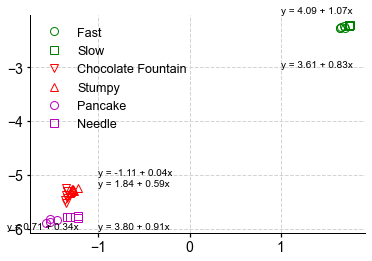

In [39]:
##### PLOTS FOR PCP #######################
a_fast,b_fast = np.polyfit( bnb_cat_sr['Fast'].values, bnb_cat_mg['Fast'].values, 1 )
#plt.plot(bnb_cat_sr['Fast'].values, a_fast*bnb_cat_sr['Fast'].values+b_fast, color='steelblue', linestyle='--', linewidth=2)
plt.text(1, -2, 'y = ' + '{:.2f}'.format(b_fast) + ' + {:.2f}'.format(a_fast) + 'x', size=10)
plt.plot(bnb_cat_mg['Fast'].values, bnb_cat_sr['Fast'].values, 'go', markerfacecolor = 'none', markersize = 8, label = 'Fast')

a_slow,b_slow = np.polyfit( bnb_cat_sr['Slow'].values, bnb_cat_mg['Slow'].values, 1 )
#plt.plot(bnb_cat_sr['Fast'].values, a_slow*bnb_cat_sr['Fast'].values+b_slow, color='steelblue', linestyle='--', linewidth=2)
plt.text(1, -3, 'y = ' + '{:.2f}'.format(b_slow) + ' + {:.2f}'.format(a_slow) + 'x', size=10)
plt.plot(bnb_cat_mg['Slow'].values, bnb_cat_sr['Slow'].values, 'gs', markerfacecolor = 'none', markersize = 8, label = 'Slow')

a_cf,b_cf = np.polyfit( ppur_cat_sr['Chocolate Fountain'].values,ppur_cat_mg['Chocolate Fountain'].values, 1 )
#plt.plot(ppur_cat_sr['Chocolate Fountain'].values, a_cf*ppur_cat_sr['Chocolate Fountain'].values+b_cf, color='steelblue', linestyle='--', linewidth=2)
plt.text(-1, -5, 'y = ' + '{:.2f}'.format(b_cf) + ' + {:.2f}'.format(a_cf) + 'x', size=10)
plt.plot(ppur_cat_mg['Chocolate Fountain'].values,ppur_cat_sr['Chocolate Fountain'].values, 'rv', markerfacecolor = 'none', markersize = 8, label = 'Chocolate Fountain')

idx = np.isfinite(ppur_cat_sr['Stumpy'].values) & np.isfinite(ppur_cat_mg['Stumpy'].values)
a_stumpy,b_stumpy = np.polyfit( ppur_cat_sr['Stumpy'][idx].values,ppur_cat_mg['Stumpy'][idx].values, 1 )
#plt.plot(ppur_cat_sr['Stumpy'].values, a_stumpy*ppur_cat_sr['Stumpy'].values+b_cf, color='steelblue', linestyle='--', linewidth=2)
plt.text(-1, -5.2, 'y = ' + '{:.2f}'.format(b_stumpy) + ' + {:.2f}'.format(a_stumpy) + 'x', size=10)
plt.plot(ppur_cat_mg['Stumpy'].values,ppur_cat_sr['Stumpy'].values, 'r^', markerfacecolor = 'none', markersize = 8, label = 'Stumpy')

idx = np.isfinite(banga_cat_sr['Pancake'].values) & np.isfinite(banga_cat_mg['Pancake'].values)
a_pc,b_pc = np.polyfit( banga_cat_sr['Pancake'][idx].values,banga_cat_mg['Pancake'][idx].values, 1 )
#plt.plot(banga_cat_sr['Pancake'].values, a_pc*banga_cat_sr['Pancake'].values+b_pc, color='steelblue', linestyle='--', linewidth=2)
plt.text(-1, -6, 'y = ' + '{:.2f}'.format(b_pc) + ' + {:.2f}'.format(a_pc) + 'x', size=10)
plt.plot(banga_cat_mg['Pancake'].values,banga_cat_sr['Pancake'].values, 'mo', markerfacecolor = 'none', markersize = 8, label = 'Pancake')


idx = np.isfinite(banga_cat_sr['Needle'].values) & np.isfinite(banga_cat_mg['Needle'].values)
a_needle,b_needle = np.polyfit( banga_cat_sr['Needle'][idx].values, banga_cat_mg['Needle'][idx].values, 1 )
#plt.plot(banga_cat_sr['Needle'].values, a_needle*banga_cat_sr['Needle'].values+b_needle, color='steelblue', linestyle='--', linewidth=2)
plt.text(-2, -6, 'y = ' + '{:.2f}'.format(b_needle) + ' + {:.2f}'.format(a_needle) + 'x', size=10)
plt.plot(banga_cat_mg['Needle'].values, banga_cat_sr['Needle'].values, 'ms', markerfacecolor = 'none', markersize = 8, label = 'Needle')
#plt.ylim([-2 ,2])
plt.legend()
#plt.savefig('Figures/PCP.eps')
plt.show()

In [62]:
m.instr_df

{'Science Garden Daily Data.csv':           Date  RAINFALL  TMAX  TMIN  TMEAN  RH  WIND_SPEED  WIND_DIRECTION  \
 0   2022-01-01       0.0  29.4  22.4  25.90  67           1              60   
 1   2022-01-02       0.0  29.2  21.1  25.10  69           1              40   
 2   2022-01-03       0.0  30.0  21.5  25.80  63           1              20   
 3   2022-01-04       0.0  30.0  22.2  26.10  65           1             150   
 4   2022-01-05       0.0  30.4  22.7  26.50  65           1             350   
 ..         ...       ...   ...   ...    ...  ..         ...             ...   
 541 2023-06-26       0.8  31.3  25.0  28.15  79           1              70   
 542 2023-06-27       0.0  32.3  26.4  29.35  77           1              10   
 543 2023-06-28      20.6  34.3  25.7  30.00  77           1             160   
 544 2023-06-29       0.0  32.3  26.2  29.25  82           1             180   
 545 2023-06-30       0.0  32.2  26.5  29.35  75           1             290   
 
     

In [ ]:
plt.plot()

In [1]:
# CO2 data daily
bulacan_CO2 = m.cave_df['Bulacan']
bulacan_CO2.index = bulacan_CO2['Date']
bulacan_CO2_daily = bulacan_CO2.resample('D').mean().reset_index(names = 'Time')
bulacan_CO2_daily['NDate'] = bulacan_CO2_daily['Date'].map(lambda  x: x.year + ( (x.month-1)/12) + x.day/365  )

NameError: name 'm' is not defined

NaNs have been detected and dropped.
Time axis values sorted in ascending order


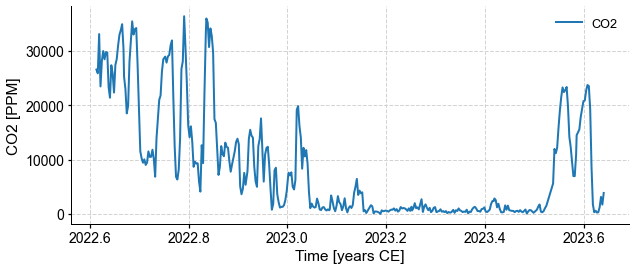

In [187]:
# BULACAN CO2
ts_bul_co2 = pyleo.Series(time=bulacan_CO2_daily['NDate'], value=bulacan_CO2_daily['CO2'],
                  time_name='Years', value_name='CO2',
                  time_unit='CE', value_unit='PPM',
                  label='CO2', clean_ts=True)
fig, ax      = ts_bul_co2.plot()

/Users/natashasekhon/Library/Python/3.9/lib/python/site-packages/pyleoclim/utils/tsutils.py:980: UserWarning: Timeseries is not evenly-spaced, interpolating...
  warnings.warn("Timeseries is not evenly-spaced, interpolating...")
Performing wavelet analysis on individual series: 100%|████████████████████████████████████████████████████████████████████████████████████████| 200/200 [43:47<00:00, 13.14s/it]


Significance threshold 0.95 not found in qs. Picking the closest, which is 0.90


(<Figure size 720x576 with 2 Axes>,
 <Axes: title={'center': 'CO2 scalogram (WWZ) with 90% threshold'}, xlabel='Time [years CE]', ylabel='Scale [years CEs]'>)

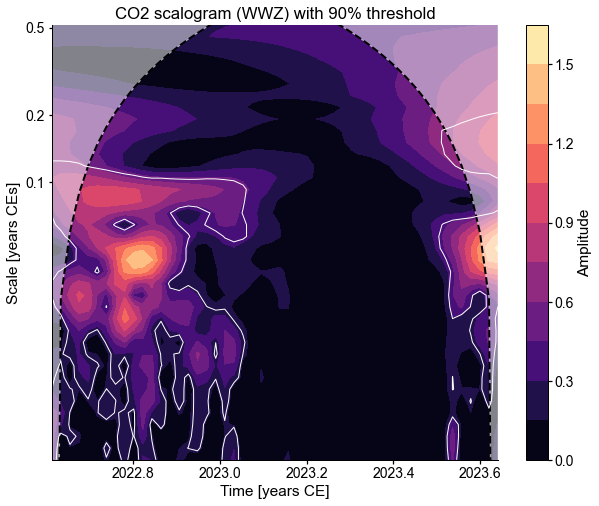

In [149]:
ts_bul_co2.detrend(method='savitzky-golay').standardize().wavelet(method='wwz').signif_test(method = 'ar1sim',qs=[0.90]).plot()

In [36]:
plates  = pd.read_excel('Data/Chemical/plates_iso.xlsx', sheet_name='v2')
plates.columns

Index(['Identifier 1', 'Identifier 2', 'Date Collected', 'Weight [mg]',
       'd 13C/12C  Mean', 'd 13C/12C  Std.Dev.', 'd 18O/16O  Mean',
       'd 18O/16O  Std.Dev.', 'Rainfall', 'Temp', 'Wind_Direction'],
      dtype='object')

[-13.037 -14.148 -14.011 -12.662]
[-0.06913861]
r2: 0.04
X.shape : (4,)
y.shape : (4,)


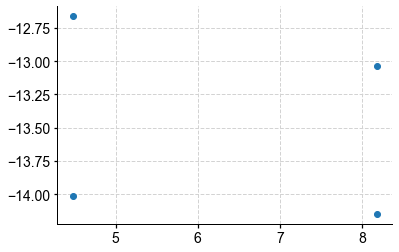

In [37]:
from sklearn.linear_model import LinearRegression
y = np.array ( plates['d 13C/12C  Mean'] ) #dependent 
print(y)
X_rain = np.array ( plates['Rainfall'] )
plt.scatter(X_rain, y)
#print(X.shape)

reg = LinearRegression().fit( X_rain.reshape(-1, 1), y)
print( reg.coef_ )
print( f'r2: {round( reg.score(X_rain.reshape(-1, 1), y),2 )}')

print('X.shape :', X_rain.shape )
print( 'y.shape :', y.shape)

In [25]:
 #dependent X = np.array ( plates['Temp'] )
#print(X.shape)

X = np.array ( plates['Temp'] )
print(X)
reg = LinearRegression().fit( X.reshape(-1, 1), y)
print( reg.coef_ )
print( f'r2: {round( reg.score(X.reshape(-1, 1), y),2 )}')

print('X.shape :', X.shape )

[28.215      28.215      28.11056338 28.11056338]
[-2.45124747]
r2: 0.04
X.shape : (4,)


In [26]:
X_wind = np.array ( plates['Wind_Direction'] )
print(X_wind)
#print(X.shape)

reg = LinearRegression().fit( X_wind.reshape(-1, 1), y)
print( reg.coef_ )
print( f'r2: {round( reg.score(X_wind.reshape(-1, 1), y),2 )}')

print('X.shape :', X_wind.shape )


[159 159 110 110]
[-0.00522449]
r2: 0.04
X.shape : (4,)


In [27]:
import statsmodels.api as sm
x = plates[['Rainfall','Temp','Wind_Direction']]

x = sm.add_constant(x) # adding a constant
 
model = sm.OLS(y, x).fit()
predictions = model.predict(x) 
 
print_model = model.summary()
print(print_model)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                 -0.438
Method:                 Least Squares   F-statistic:                   0.08583
Date:                Sat, 08 Jul 2023   Prob (F-statistic):              0.797
Time:                        11:33:56   Log-Likelihood:                -3.7499
No. Observations:                   4   AIC:                             11.50
Df Residuals:                       2   BIC:                             10.27
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0161      0.003     -5.

/Users/natashasekhon/Library/Python/3.9/lib/python/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/Users/natashasekhon/Library/Python/3.9/lib/python/site-packages/statsmodels/regression/linear_model.py:1965: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])


In [176]:
#### PLOT CROSS PLOT

#### Ca [mmol/L] versus Mg/Ca
#### SO4 [uMol/l] vs Cl [uMol/l]
#### Na [uMol/l] vs Cl [uMol/l]
#### [Cations/Ca] vs [Mg/Ca] [mMol/Mol]

cross_plot_df_PPUR = pd.read_excel('Data/Chemical/Water/cross_plots.xlsx', sheet_name='PPUR')
cross_plot_df_BNB = pd.read_excel('Data/Chemical/Water/cross_plots.xlsx', sheet_name='BNB')
cross_plot_df_BAN = pd.read_excel('Data/Chemical/Water/cross_plots.xlsx', sheet_name='Bangalau')

In [177]:
cl_BNB  = pd.pivot_table(cross_plot_df_BNB.reset_index(),index='Date', columns='Site Name', values=['Cl-_umol/L'])
na_BNB  = pd.pivot_table(cross_plot_df_BNB.reset_index(),index='Date', columns='Site Name', values=['Na_umol/L'])
so4_BNB = pd.pivot_table(cross_plot_df_BNB.reset_index(),index='Date', columns='Site Name', values=['SO42-_umol/L'])
ca_BNB  = pd.pivot_table(cross_plot_df_BNB.reset_index(),index='Date', columns='Site Name', values=['Ca_mmol/L'])
mgca_BNB  = pd.pivot_table(cross_plot_df_BNB.reset_index(),index='Date', columns='Site Name', values=['Mg/Ca_mmol/mol'])

cl_PPUR = pd.pivot_table(cross_plot_df_PPUR.reset_index(),index='Date', columns='Site Name', values=['Cl-_umol/L'])
na_PPUR = pd.pivot_table(cross_plot_df_PPUR.reset_index(),index='Date', columns='Site Name', values=['Na_umol/L'])
so4_PPUR = pd.pivot_table(cross_plot_df_PPUR.reset_index(),index='Date', columns='Site Name', values=['SO42-_umol/L'])
ca_PPUR  = pd.pivot_table(cross_plot_df_PPUR.reset_index(),index='Date', columns='Site Name', values=['Ca_mmol/L'])
mgca_PPUR  = pd.pivot_table(cross_plot_df_PPUR.reset_index(),index='Date', columns='Site Name', values=['Mg/Ca_mmol/mol'])

cl_BAN = pd.pivot_table(cross_plot_df_BAN.reset_index(),index='Date', columns='Site Name', values=['Cl-_umol/L'])
na_BAN = pd.pivot_table(cross_plot_df_BAN.reset_index(),index='Date', columns='Site Name', values=['Na_umol/L'])
so4_BAN = pd.pivot_table(cross_plot_df_BAN.reset_index(),index='Date', columns='Site Name', values=['SO42-_umol/L'])
ca_BAN  = pd.pivot_table(cross_plot_df_BAN.reset_index(),index='Date', columns='Site Name', values=['Ca_mmol/L'])
mgca_BAN  = pd.pivot_table(cross_plot_df_BAN.reset_index(),index='Date', columns='Site Name', values=['Mg/Ca_mmol/mol'])

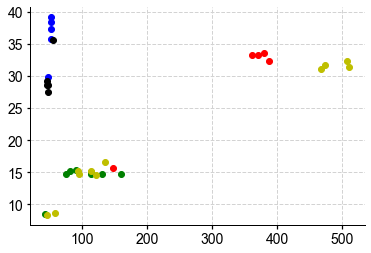

In [174]:
plt.plot(  cl_PPUR[('Cl-_umol/L', 'Chocolate Fountain')],so4_PPUR[('SO42-_umol/L', 'Chocolate Fountain')],'go' )
plt.plot( cl_PPUR[('Cl-_umol/L', 'Stumpy')],so4_PPUR[('SO42-_umol/L', 'Stumpy')], 'yo' )
plt.plot(  cl_BNB[('Cl-_umol/L', 'Slow')],so4_BNB[('SO42-_umol/L', 'Slow')],'bo' )
plt.plot(  cl_BNB[('Cl-_umol/L', 'Fast')],so4_BNB[('SO42-_umol/L', 'Fast')],'ko' )
plt.plot( cl_BAN[('Cl-_umol/L', 'Needle')],so4_BAN[('SO42-_umol/L', 'Needle')], 'yo' )
plt.plot(  cl_BAN[('Cl-_umol/L', 'Pancake')], so4_BAN[('SO42-_umol/L', 'Pancake')],'ro' )

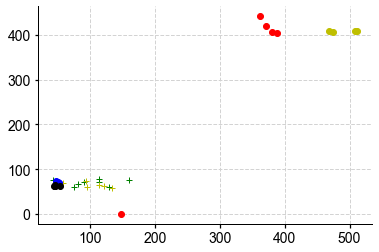

In [190]:
plt.plot(  cl_PPUR[('Cl-_umol/L', 'Chocolate Fountain')],na_PPUR[('Na_umol/L', 'Chocolate Fountain')],'g+' )
plt.plot( cl_PPUR[('Cl-_umol/L', 'Stumpy')],na_PPUR[('Na_umol/L', 'Stumpy')], 'y+' )
plt.plot(  cl_BNB[('Cl-_umol/L', 'Slow')],na_BNB[('Na_umol/L', 'Slow')],'bo' )
plt.plot(  cl_BNB[('Cl-_umol/L', 'Fast')],na_BNB[('Na_umol/L', 'Fast')],'ko' )
plt.plot( cl_BAN[('Cl-_umol/L', 'Needle')],na_BAN[('Na_umol/L', 'Needle')], 'yo' )
plt.plot(  cl_BAN[('Cl-_umol/L', 'Pancake')], na_BAN[('Na_umol/L', 'Pancake')],'ro' )
plt.savefig('Figures/sea_water.eps')

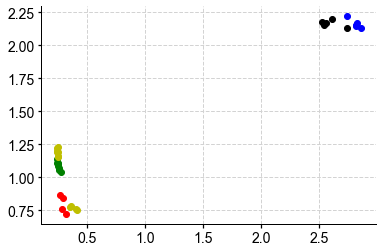

In [178]:
plt.plot(  mgca_PPUR[('Mg/Ca_mmol/mol', 'Chocolate Fountain')],ca_PPUR[('Ca_mmol/L', 'Chocolate Fountain')],'go' )
plt.plot( mgca_PPUR[('Mg/Ca_mmol/mol', 'Stumpy')],ca_PPUR[('Ca_mmol/L', 'Stumpy')], 'yo' )
plt.plot(  mgca_BNB[('Mg/Ca_mmol/mol', 'Slow')],ca_BNB[('Ca_mmol/L', 'Slow')],'bo' )
plt.plot(  mgca_BNB[('Mg/Ca_mmol/mol', 'Fast')],ca_BNB[('Ca_mmol/L', 'Fast')],'ko' )
plt.plot( mgca_BAN[('Mg/Ca_mmol/mol', 'Needle')],ca_BAN[('Ca_mmol/L', 'Needle')], 'yo' )
plt.plot(  mgca_BAN[('Mg/Ca_mmol/mol', 'Pancake')], ca_BAN[('Ca_mmol/L', 'Pancake')],'ro' )

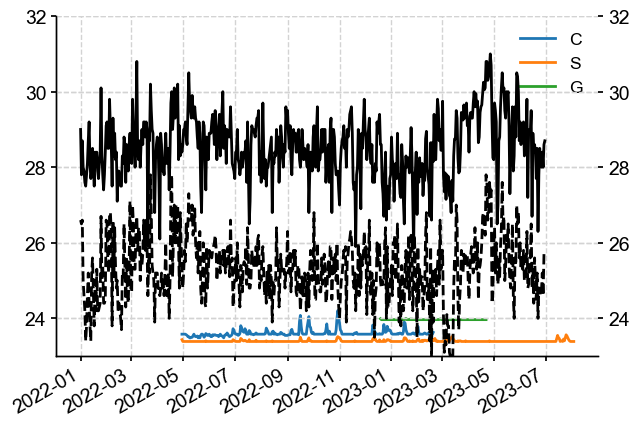

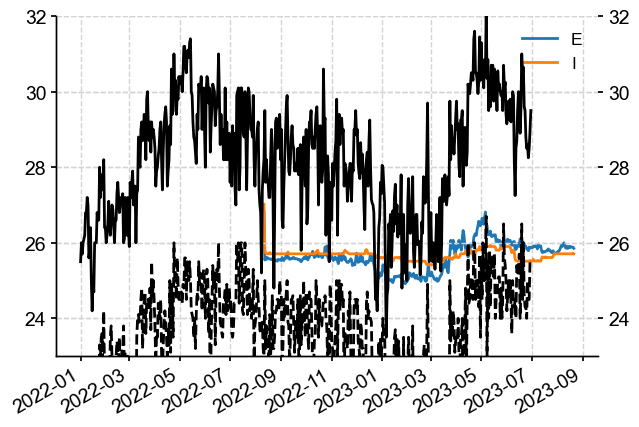

In [41]:
fig, ax1 = plt.subplots(figsize=(7,5), dpi=100)
ax2 = ax1.twinx()
ax1.plot( m.cave_df['Palawan']['Date'], m.cave_df['Palawan']['CF_Temp'] )
ax1.plot( m.cave_df['Palawan']['Date'], m.cave_df['Palawan']['Stumpy_Temp'] )
ax1.plot( m.cave_df['Palawan']['Date'], m.cave_df['Palawan']['Goblin_Temp'] )
ax1.legend('CSG')
ax1.set_ylim([23,32])
ax2.plot( m.instr_df['Puerto.csv']['Date'], m.instr_df['Puerto.csv']['TMEAN'],'k')
ax2.plot( m.instr_df['Puerto.csv']['Date'], m.instr_df['Puerto.csv']['TMIN'],'k--')
ax2.set_ylim([23,32])
fig.autofmt_xdate()
plt.savefig('Figures/temp_PPR.eps')




fig, ax1 = plt.subplots(figsize=(7,5), dpi=100)
ax2 = ax1.twinx()
ax1.plot( m.cave_df['Bulacan']['Date'], m.cave_df['Bulacan']['Entrance_Temp'] )
ax1.plot( m.cave_df['Bulacan']['Date'], m.cave_df['Bulacan']['Interior_Temp'] )
ax1.legend('EI')
ax1.set_ylim([23,32])
ax2.plot( m.instr_df['CLSU.csv']['Date'], m.instr_df['CLSU.csv']['TMEAN'],'k')
ax2.plot( m.instr_df['CLSU.csv']['Date'], m.instr_df['CLSU.csv']['TMIN'],'k--')
ax2.set_ylim([23,32])
fig.autofmt_xdate()
plt.savefig('Figures/temp_BNB.eps')



In [19]:
m.instr_df

{'Science Garden Daily Data.csv':           Date  RAINFALL  TMAX  TMIN  TMEAN  RH  WIND_SPEED  WIND_DIRECTION  \
 0   2022-01-01       0.0  29.4  22.4  25.90  67           1              60   
 1   2022-01-02       0.0  29.2  21.1  25.10  69           1              40   
 2   2022-01-03       0.0  30.0  21.5  25.80  63           1              20   
 3   2022-01-04       0.0  30.0  22.2  26.10  65           1             150   
 4   2022-01-05       0.0  30.4  22.7  26.50  65           1             350   
 ..         ...       ...   ...   ...    ...  ..         ...             ...   
 541 2023-06-26       0.8  31.3  25.0  28.15  79           1              70   
 542 2023-06-27       0.0  32.3  26.4  29.35  77           1              10   
 543 2023-06-28      20.6  34.3  25.7  30.00  77           1             160   
 544 2023-06-29       0.0  32.3  26.2  29.25  82           1             180   
 545 2023-06-30       0.0  32.2  26.5  29.35  75           1             290   
 
     

In [125]:
x_P = m.instr_df['Puerto.csv'] [m.instr_df['Puerto.csv']['PRESSURE']<1004]
x_B = m.instr_df['CLSU.csv'] [m.instr_df['CLSU.csv']['PRESSURE']<1000]
x_B1= m.instr_df['CLSU.csv'] [m.instr_df['CLSU.csv']['PRESSURE']<997]
x_C = m.instr_df['Aparri.csv'] [m.instr_df['Aparri.csv']['PRESSURE']<1000]
x_C1 = m.instr_df['Aparri.csv'] [m.instr_df['Aparri.csv']['PRESSURE']<997]

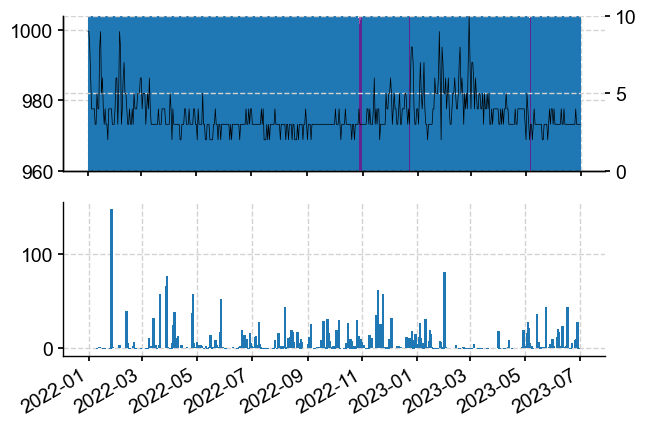

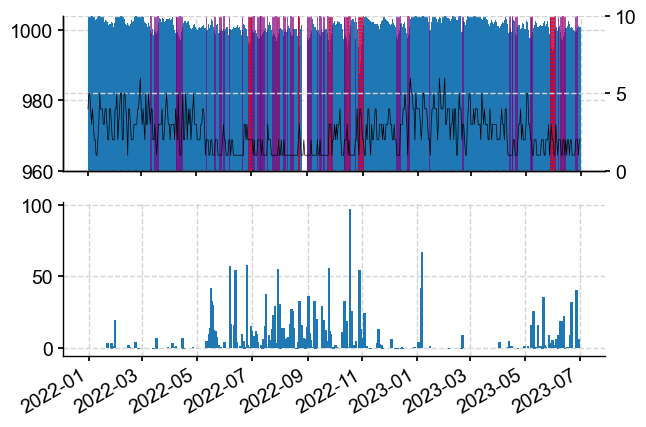

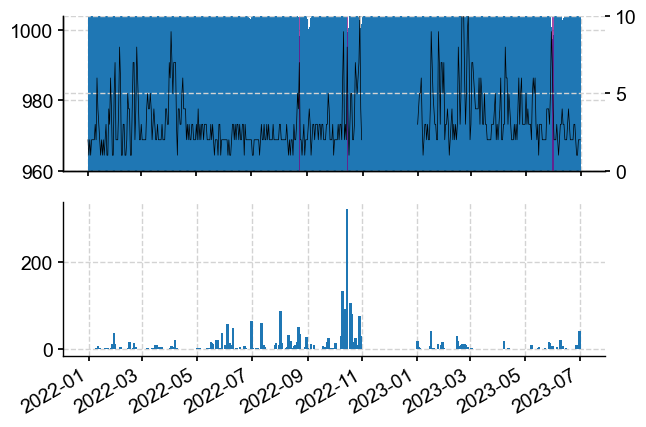

In [128]:
fig, (ax1,ax3) = plt.subplots(2,figsize=(7,5), dpi=100)
ax2 = ax1.twinx()
ax1.bar( m.instr_df['Puerto.csv']['Date'], m.instr_df['Puerto.csv']['PRESSURE'],width=1)
ax1.vlines(x = x_P['Date']
           , ymin = 0, ymax = 1004,
           colors = 'purple',
           label = 'vline_multiple - full height',linewidth = 0.5)
ax1.set_ylim([960,1004])
ax2.plot( m.instr_df['Puerto.csv']['Date'], m.instr_df['Puerto.csv']['WIND_SPEED'],'k',linewidth = '0.5')
ax2.set_ylim([0,10])
ax3.bar( m.instr_df['Puerto.csv']['Date'], m.instr_df['Puerto.csv']['RAINFALL'],width=2.8)
fig.autofmt_xdate()
plt.savefig('Figures/rain_PPR.eps')




fig, (ax1,ax3) = plt.subplots(2,figsize=(7,5), dpi=100)
ax2 = ax1.twinx()
ax1.bar( m.instr_df['CLSU.csv']['Date'], m.instr_df['CLSU.csv']['PRESSURE'],width=1)
ax1.vlines(x = x_B['Date']
           , ymin = 0, ymax = 1080,
           colors = 'purple',
           label = 'vline_multiple - full height',linewidth = 0.5)
ax1.vlines(x = x_B1['Date']
           , ymin = 0, ymax = 1080,
           colors = 'red',
           label = 'vline_multiple - full height',linewidth = 0.5,linestyles = 'dashed')
ax1.set_ylim([960,1004])
ax2.plot( m.instr_df['CLSU.csv']['Date'], m.instr_df['CLSU.csv']['WIND_SPEED'],'k',linewidth = '0.5')
ax2.set_ylim([0,10])
ax3.bar( m.instr_df['CLSU.csv']['Date'], m.instr_df['CLSU.csv']['RAINFALL'],width=2.8)
fig.autofmt_xdate()
plt.savefig('Figures/rain_BNB.eps')


fig, (ax1,ax3) = plt.subplots(2,figsize=(7,5), dpi=100)
ax2 = ax1.twinx()
ax1.bar( m.instr_df['Aparri.csv']['Date'], m.instr_df['Aparri.csv']['PRESSURE'],width=1)
ax1.vlines(x = x_C['Date']
           , ymin = 0, ymax = 1080,
           colors = 'purple',
           label = 'vline_multiple - full height',linewidth = 0.5)
ax1.vlines(x = x_C1['Date']
           , ymin = 0, ymax = 1080,
           colors = 'red',
           label = 'vline_multiple - full height',linewidth = 0.5,linestyles = 'dashed')
ax1.set_ylim([960,1004])
ax2.plot( m.instr_df['Aparri.csv']['Date'], m.instr_df['Aparri.csv']['WIND_SPEED'],'k',linewidth = '0.5')
ax2.set_ylim([0,10])
ax3.bar( m.instr_df['Aparri.csv']['Date'], m.instr_df['Aparri.csv']['RAINFALL'],width=2.8)
fig.autofmt_xdate()
plt.savefig('Figures/rain_Aparri.eps')

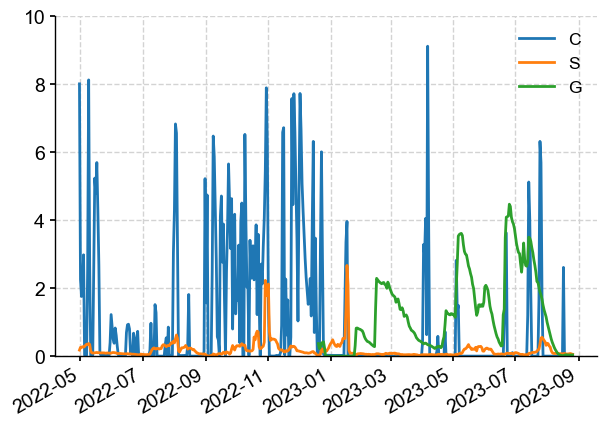

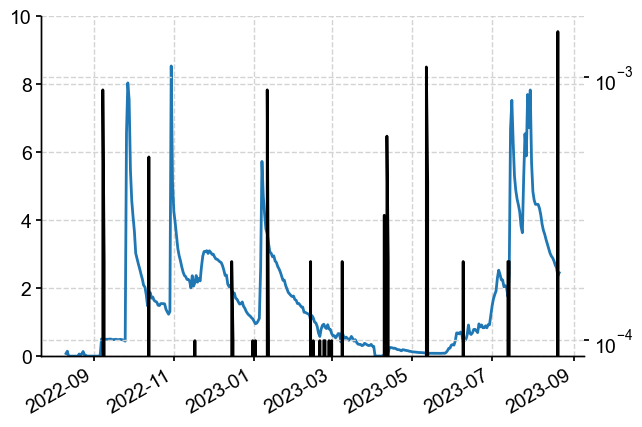

In [184]:
fig, ax = plt.subplots(figsize=(7,5), dpi=100)
ax.plot( m.cave_df['Palawan']['Date'], m.cave_df['Palawan']['cf_ml/min'] )
ax.plot( m.cave_df['Palawan']['Date'], m.cave_df['Palawan']['stumpy_ml/min_x'] )
ax.plot( m.cave_df['Palawan']['Date'], m.cave_df['Palawan']['goblin_ml/min'] )
ax.legend('CSG')
ax.set_ylim([0,10])
fig.autofmt_xdate()
plt.savefig('Figures/drip_PPR.eps')


fig, ax1 = plt.subplots(figsize=(7,5), dpi=100)
ax2 = ax1.twinx()
ax1.plot( m.cave_df['Bulacan']['Date'], m.cave_df['Bulacan']['fast_ml/min'] )
ax1.set_ylim([0,10])
ax2.plot( m.cave_df['Bulacan']['Date'], m.cave_df['Bulacan']['slow_ml/min'],'k' )
ax2.set_yscale('log')
ax1.set_ylim([0,10])
fig.autofmt_xdate()
plt.savefig('Figures/drip_BNB.eps')




In [129]:
m.cave_df

{'Bulacan':           Date  Entrance_Temp  Interior_Temp   Fast_Count  fast_drops/minute  \
 0   2022-08-11      26.824000      27.018667   129.500000           0.539583   
 1   2022-08-12      25.545333      25.805000   243.833333           1.015972   
 2   2022-08-13      25.610167      25.740333     0.000000           0.000000   
 3   2022-08-14      25.561500      25.708000     0.000000           0.000000   
 4   2022-08-15      25.610000      25.708000     0.000000           0.000000   
 ..         ...            ...            ...          ...                ...   
 371 2023-08-17      25.902333      25.708000  4691.166667          19.546528   
 372 2023-08-18      25.886000      25.708000  4489.000000          18.704167   
 373 2023-08-19      25.886000      25.708000  4345.666667          18.106944   
 374 2023-08-20      25.886000      25.724167  3951.000000          16.462500   
 375 2023-08-21      25.853500      25.708000  4105.750000          17.107292   
 
      fast_ml/m

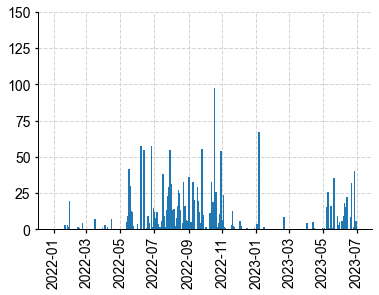

In [67]:
plt.bar( m.instr_df['CLSU.csv']['Date'], m.instr_df['CLSU.csv']['RAINFALL'],width=2.8)
plt.ylim(0,150)
plt.xticks(rotation=90)
plt.savefig('Figures/bnb_AGU2023.eps')

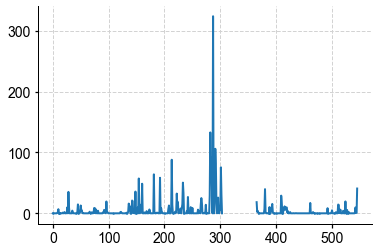

In [66]:
plt.plot(m.instr_df['Aparri.csv']['RAINFALL'])